In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
filepath = "../Raw/Gross savings %/API_NY.GNS.ICTR.ZS_DS2_en_csv_v2_260.csv"
df = pd.read_csv(filepath, skiprows=4)
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Gross savings (% of GDP),NY.GNS.ICTR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,13.576167,11.042864,11.154439,3.688977,8.943166,14.914966,19.588083,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Gross savings (% of GDP),NY.GNS.ICTR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.625829,18.567395,19.188164,18.337005,20.065367,19.459890,18.277838,17.817472,NaN,NaN
2,Afghanistan,AFG,Gross savings (% of GDP),NY.GNS.ICTR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-2.737769,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Gross savings (% of GDP),NY.GNS.ICTR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Gross savings (% of GDP),NY.GNS.ICTR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,28.510035,30.617972,30.060924,20.942426,25.690421,22.371567,15.950105,15.726693,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Gross savings (% of GDP),NY.GNS.ICTR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,29.281603,28.635588,28.879968,26.583254,27.217355,25.069147,26.607413,25.541733,NaN,NaN
262,"Yemen, Rep.",YEM,Gross savings (% of GDP),NY.GNS.ICTR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Gross savings (% of GDP),NY.GNS.ICTR.ZS,27.81245,28.573596,29.215407,30.87837,29.461358,30.273166,...,14.243707,13.230245,13.216015,14.308190,16.565600,15.339833,14.715950,13.581504,NaN,NaN
264,Zambia,ZMB,Gross savings (% of GDP),NY.GNS.ICTR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,43.287245,41.896036,39.786009,46.415646,45.138757,45.410091,34.464482,34.421066,NaN,NaN


In [4]:
# Get the year columns
yr_cols = [col for col in df.columns if col.startswith('20') or col.startswith('19')]
# Convert year columns to numeric, coercing errors to NaN
df[yr_cols] = df[yr_cols].apply(pd.to_numeric, errors='coerce')

In [5]:
# Melt the DataFrame to long format
# 'Country Name', 'Country Code', 'Indicator Name', 'Indicator Code' are id_vars
id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
df_long = df.melt(id_vars=id_vars, value_vars=yr_cols, var_name='Year', value_name='Gross Savings % of GDP')
df_long

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Gross Savings % of GDP
0,Aruba,ABW,Gross savings (% of GDP),NY.GNS.ICTR.ZS,1960,NaN
1,Africa Eastern and Southern,AFE,Gross savings (% of GDP),NY.GNS.ICTR.ZS,1960,NaN
2,Afghanistan,AFG,Gross savings (% of GDP),NY.GNS.ICTR.ZS,1960,NaN
3,Africa Western and Central,AFW,Gross savings (% of GDP),NY.GNS.ICTR.ZS,1960,NaN
4,Angola,AGO,Gross savings (% of GDP),NY.GNS.ICTR.ZS,1960,NaN
...,...,...,...,...,...,...
17551,Kosovo,XKX,Gross savings (% of GDP),NY.GNS.ICTR.ZS,2025,NaN
17552,"Yemen, Rep.",YEM,Gross savings (% of GDP),NY.GNS.ICTR.ZS,2025,NaN
17553,South Africa,ZAF,Gross savings (% of GDP),NY.GNS.ICTR.ZS,2025,NaN
17554,Zambia,ZMB,Gross savings (% of GDP),NY.GNS.ICTR.ZS,2025,NaN


In [6]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country Name            17556 non-null  object 
 1   Country Code            17556 non-null  object 
 2   Indicator Name          17556 non-null  object 
 3   Indicator Code          17556 non-null  object 
 4   Year                    17556 non-null  object 
 5   Gross Savings % of GDP  7818 non-null   float64
dtypes: float64(1), object(5)
memory usage: 823.1+ KB


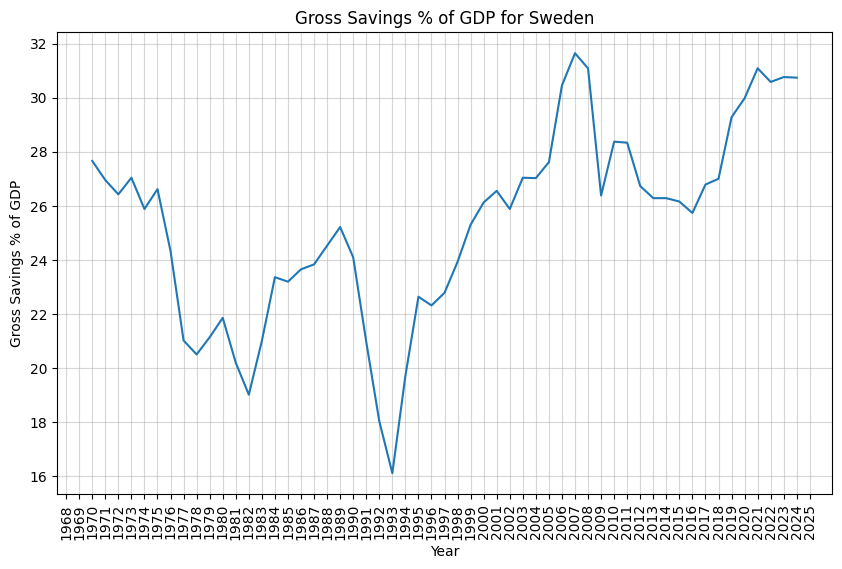

In [10]:
# Inspect sweden
swe = df_long[df_long['Country Name'] == 'Sweden'].sort_values('Year')
plt.figure(figsize=(10, 6))
sns.lineplot(data=swe, x='Year', y='Gross Savings % of GDP')
plt.title('Gross Savings % of GDP for Sweden')
plt.xlabel('Year')
plt.ylabel('Gross Savings % of GDP')
plt.xticks(rotation=90)
plt.grid(alpha=0.5)
plt.show()

In [11]:
# Add iso3 code as the country code
df_long["iso3"] = df_long["Country Code"]

In [12]:
# Export to clean csv
df_long.to_csv("../Clean/gross_savings.csv", index=False)